<a href="https://colab.research.google.com/github/SiyuL2025/math_629_final/blob/main/BTC%2BETH_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. DOWNLOAD AND LOAD DATA


100%|██████████| 993M/993M [00:15<00:00, 67.9MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/martinsn/high-frequency-crypto-limit-order-book-data/versions/1
BTC shape: (100000, 156)
ETH shape: (100000, 156)

2. TIME ALIGNMENT
BTC time range: 2021-04-07 11:32:42+00:00 → 2021-04-08 15:19:54+00:00
ETH time range: 2021-04-07 11:32:50+00:00 → 2021-04-08 15:19:46+00:00
After merge: (99972, 160)  (99,972 rows retained)

3. FEATURE ENGINEERING
Shape after dropna: (99902, 178)
Label distribution:
label
-1    31426
 0    37159
 1    31317

LOB features   : 60
Market features: 15

4. PCA
LOB features : 60
PCA components retained (90% variance): 30
Train PCA shape: (79921, 30)
Test  PCA shape: (19981, 30)

5. PCA DIAGNOSTICS


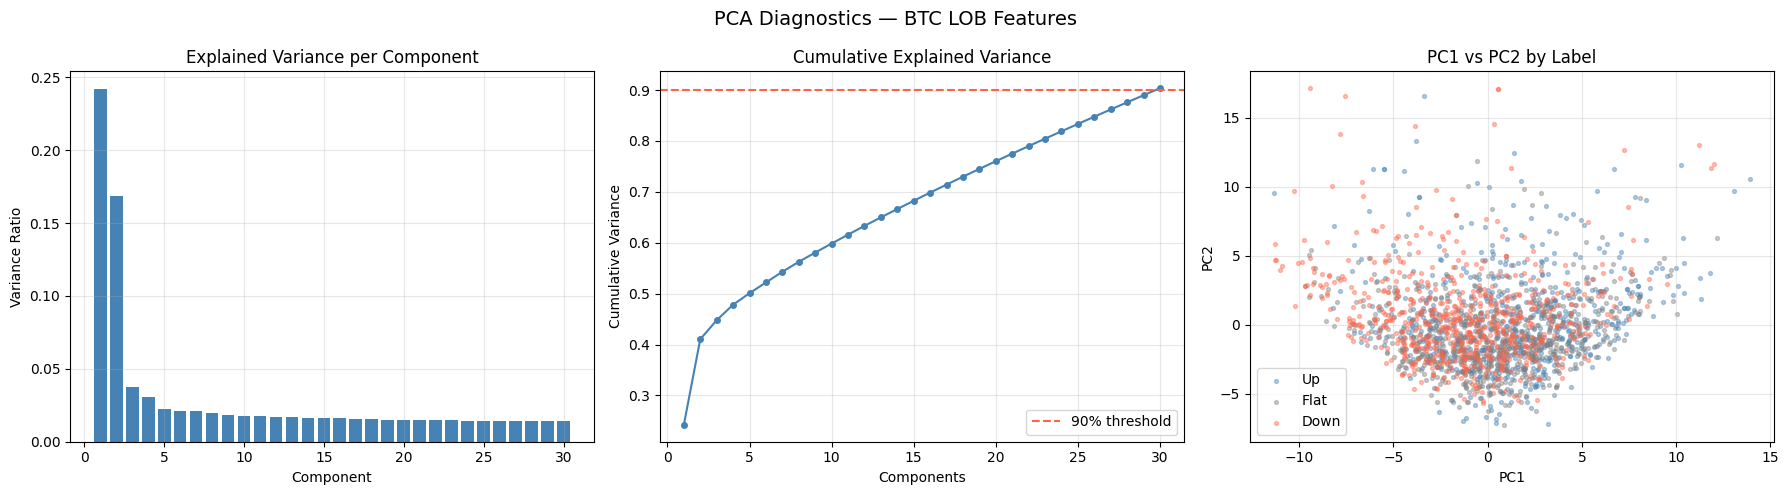


6. FINAL DATASET ASSEMBLY
X_final shape  : (99902, 45)
Y_final shape  : (99902,)

Feature breakdown:
  PCA components : 30
  Market features: 15
  Total          : 45

Train / Test split index: 79921


,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,pca_10,...,btc_momentum_60s,eth_spread,eth_oimb_1,eth_volatility_10s,eth_volatility_60s,eth_momentum_10s,eth_momentum_60s,btc_eth_momentum_diff_10s,btc_eth_momentum_diff_60s,btc_eth_vol_ratio_10s
0,1.997145,7.441477,0.048101,1.310962,-1.132676,1.936455,0.292069,-0.853289,0.310951,-0.382409,...,-0.003200,0.01,-0.396305,0.000207,0.000253,-0.000506,-0.002474,-0.000195,-0.000726,1.028826
1,-3.522458,7.080465,-2.195006,0.526237,-2.140027,2.047595,0.519002,1.086173,0.014582,0.268709,...,-0.003156,0.39,-0.679389,0.000199,0.000253,-0.000605,-0.002443,-0.000055,-0.000713,1.076590
2,2.390608,9.200963,4.302600,1.919440,-2.437481,0.735135,-0.235451,0.792108,-0.357739,1.224468,...,-0.003354,0.03,0.522530,0.000204,0.000253,-0.000389,-0.002347,-0.000442,-0.001007,1.068719
3,-5.630498,13.420166,-3.047943,-0.564960,-0.783937,-0.654891,-0.354128,-1.107642,-0.806801,0.383663,...,-0.003425,0.36,-0.196982,0.000167,0.000253,-0.000114,-0.002456,-0.000544,-0.000969,1.256562
4,-6.412811,12.154399,-1.252472,0.173083,-1.683628,0.688104,0.254088,-0.199066,0.376749,1.433366,...,-0.003336,0.21,0.704133,0.000168,0.000253,-0.000043,-0.002489,-0.000218,-0.000847,1.169641


In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# ==========================================
# 1. Download and Load Data
# ==========================================
print("=" * 50)
print("1. DOWNLOAD AND LOAD DATA")
print("=" * 50)

dataset_path = kagglehub.dataset_download("martinsn/high-frequency-crypto-limit-order-book-data")
print(f"Dataset path: {dataset_path}")

btc = pd.read_csv(os.path.join(dataset_path, 'BTC_1sec.csv'), nrows=100000)
eth = pd.read_csv(os.path.join(dataset_path, 'ETH_1sec.csv'), nrows=100000)
print(f"BTC shape: {btc.shape}")
print(f"ETH shape: {eth.shape}")


# ==========================================
# 2. Time Alignment
# ==========================================
print("\n" + "=" * 50)
print("2. TIME ALIGNMENT")
print("=" * 50)

# Parse timestamps
btc['system_time'] = pd.to_datetime(btc['system_time'], utc=True)
eth['system_time'] = pd.to_datetime(eth['system_time'], utc=True)

# Floor to second to handle microsecond mismatch between BTC and ETH feeds
btc['time_key'] = btc['system_time'].dt.floor('s')
eth['time_key'] = eth['system_time'].dt.floor('s')

print(f"BTC time range: {btc['time_key'].min()} → {btc['time_key'].max()}")
print(f"ETH time range: {eth['time_key'].min()} → {eth['time_key'].max()}")

# Slim down ETH to only the columns needed for market features
eth_slim = eth[['time_key', 'midpoint', 'spread',
                 'bids_notional_0', 'asks_notional_0']].copy()
eth_slim = eth_slim.rename(columns={
    'midpoint':        'eth_midpoint',
    'spread':          'eth_spread',
    'bids_notional_0': 'eth_bids_notional_0',
    'asks_notional_0': 'eth_asks_notional_0',
})

# Inner join — only keep rows where both assets have data at the same second
df = pd.merge(btc, eth_slim, on='time_key', how='inner')
df = df.drop(columns=['time_key']).reset_index(drop=True)
print(f"After merge: {df.shape}  ({len(df):,} rows retained)")


# ==========================================
# 3. Feature Engineering
# ==========================================
print("\n" + "=" * 50)
print("3. FEATURE ENGINEERING")
print("=" * 50)

window_short = 10   # 10-second rolling window
window_long  = 60   # 60-second rolling window

# ── BTC mid price ──────────────────────────────────────────
df['mid_price']   = df['midpoint']
df['log_return']  = np.log(df['mid_price'] / df['mid_price'].shift(1))

# ── BTC market state features ──────────────────────────────
df['btc_oimb_1'] = (
    (df['bids_notional_0'] - df['asks_notional_0']) /
    (df['bids_notional_0'] + df['asks_notional_0'] + 1e-8)
)
df['btc_volatility_10s'] = df['log_return'].rolling(window_short).std()
df['btc_volatility_60s'] = df['log_return'].rolling(window_long).std()
df['btc_momentum_10s']   = df['log_return'].rolling(window_short).sum()
df['btc_momentum_60s']   = df['log_return'].rolling(window_long).sum()

# ── ETH cross-asset features ───────────────────────────────
df['eth_log_return'] = np.log(df['eth_midpoint'] / df['eth_midpoint'].shift(1))
df['eth_oimb_1'] = (
    (df['eth_bids_notional_0'] - df['eth_asks_notional_0']) /
    (df['eth_bids_notional_0'] + df['eth_asks_notional_0'] + 1e-8)
)
df['eth_volatility_10s'] = df['eth_log_return'].rolling(window_short).std()
df['eth_volatility_60s'] = df['eth_log_return'].rolling(window_long).std()
df['eth_momentum_10s']   = df['eth_log_return'].rolling(window_short).sum()
df['eth_momentum_60s']   = df['eth_log_return'].rolling(window_long).sum()

# ── BTC-ETH cross features ─────────────────────────────────
df['btc_eth_momentum_diff_10s'] = df['btc_momentum_10s'] - df['eth_momentum_10s']
df['btc_eth_momentum_diff_60s'] = df['btc_momentum_60s'] - df['eth_momentum_60s']
df['btc_eth_vol_ratio_10s']     = (
    df['btc_volatility_10s'] / (df['eth_volatility_10s'] + 1e-8)
)

# ── Prediction labels (BTC price direction, 10s ahead) ─────
prediction_horizon = 10
label_threshold    = 0.00005

df['future_return'] = (
    (df['mid_price'].shift(-prediction_horizon) - df['mid_price'])
    / df['mid_price']
)
df['label'] = np.select(
    [df['future_return'] >  label_threshold,
     df['future_return'] < -label_threshold],
    [1, -1],
    default=0
)

# Drop NaN rows generated by rolling windows and forward shift
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Shape after dropna: {df.shape}")
print(f"Label distribution:\n{df['label'].value_counts().sort_index().to_string()}")

# Feature column lists (used downstream)
lob_features = []
for i in range(15):
    lob_features.extend([
        f'bids_distance_{i}', f'asks_distance_{i}',
        f'bids_notional_{i}', f'asks_notional_{i}'
    ])

market_state_cols = [
    # BTC
    'spread',            'btc_oimb_1',
    'btc_volatility_10s','btc_volatility_60s',
    'btc_momentum_10s',  'btc_momentum_60s',
    # ETH
    'eth_spread',        'eth_oimb_1',
    'eth_volatility_10s','eth_volatility_60s',
    'eth_momentum_10s',  'eth_momentum_60s',
    # BTC-ETH divergence
    'btc_eth_momentum_diff_10s',
    'btc_eth_momentum_diff_60s',
    'btc_eth_vol_ratio_10s',
]

print(f"\nLOB features   : {len(lob_features)}")
print(f"Market features: {len(market_state_cols)}")


# ==========================================
# 4. PCA on BTC LOB Features
# ==========================================
print("\n" + "=" * 50)
print("4. PCA")
print("=" * 50)

X_lob     = df[lob_features].values
split_idx = int(len(df) * 0.8)        # chronological 80/20 split

X_train_lob = X_lob[:split_idx]
X_test_lob  = X_lob[split_idx:]

# Standardise — fit on train only to prevent data leakage
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_lob)
X_test_scaled  = scaler.transform(X_test_lob)

# Retain components explaining 90% of variance
pca         = PCA(n_components=0.90, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"LOB features : {len(lob_features)}")
print(f"PCA components retained (90% variance): {pca.n_components_}")
print(f"Train PCA shape: {X_train_pca.shape}")
print(f"Test  PCA shape: {X_test_pca.shape}")


# ==========================================
# 5. PCA Diagnostic Plots
# ==========================================
print("\n" + "=" * 50)
print("5. PCA DIAGNOSTICS")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("PCA Diagnostics — BTC LOB Features", fontsize=14)

# ── Scree plot ─────────────────────────────────────────────
axes[0].bar(range(1, pca.n_components_ + 1),
            pca.explained_variance_ratio_, color='steelblue')
axes[0].set_title("Explained Variance per Component")
axes[0].set_xlabel("Component"); axes[0].set_ylabel("Variance Ratio")
axes[0].grid(alpha=0.3)

# ── Cumulative variance ────────────────────────────────────
cum = pca.explained_variance_ratio_.cumsum()
axes[1].plot(range(1, pca.n_components_ + 1), cum, color='steelblue', marker='o', ms=4)
axes[1].axhline(0.90, color='tomato', linestyle='--', label='90% threshold')
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Components"); axes[1].set_ylabel("Cumulative Variance")
axes[1].legend(); axes[1].grid(alpha=0.3)

# ── PC1 vs PC2 scatter by label ────────────────────────────
idx      = np.random.choice(len(X_train_pca), min(2000, len(X_train_pca)), replace=False)
y_train  = df['label'].iloc[:split_idx]
colors   = {1: 'steelblue', 0: 'gray', -1: 'tomato'}
labels_n = {1: 'Up', 0: 'Flat', -1: 'Down'}
for lbl, color in colors.items():
    mask = y_train.iloc[idx] == lbl
    axes[2].scatter(
        X_train_pca[idx][mask, 0],
        X_train_pca[idx][mask, 1],
        c=color, alpha=0.4, s=8, label=labels_n[lbl]
    )
axes[2].set_title("PC1 vs PC2 by Label")
axes[2].set_xlabel("PC1"); axes[2].set_ylabel("PC2")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ==========================================
# 6. Final Dataset Assembly
# ==========================================
print("\n" + "=" * 50)
print("6. FINAL DATASET ASSEMBLY")
print("=" * 50)

pca_cols = [f'pca_{i+1}' for i in range(pca.n_components_)]
pca_df   = pd.DataFrame(
    np.vstack((X_train_pca, X_test_pca)),
    columns=pca_cols,
    index=df.index
)

X_final = pd.concat([pca_df, df[market_state_cols]], axis=1)
Y_final = df['label']

print(f"X_final shape  : {X_final.shape}")
print(f"Y_final shape  : {Y_final.shape}")
print(f"\nFeature breakdown:")
print(f"  PCA components : {len(pca_cols)}")
print(f"  Market features: {len(market_state_cols)}")
print(f"  Total          : {X_final.shape[1]}")
print(f"\nTrain / Test split index: {split_idx}")

gc.collect()
display(X_final.head())


# ==========================================
# 7. Save Processed Data as CSV
# ==========================================
print("\n" + "=" * 50)
print("7. SAVE PROCESSED DATA")
print("=" * 50)

# 把 label 也合并进去一起保存
save_df = X_final.copy()
save_df['label'] = Y_final.values          # 原始 {-1, 0, 1}
save_df['split'] = 'test'
save_df.iloc[:split_idx, save_df.columns.get_loc('split')] = 'train'

save_df.to_csv("lob_processed.csv", index=False)
print("Saved → lob_processed.csv")
print(f"  Shape: {save_df.shape}")
print(f"  Train rows: {split_idx:,}  |  Test rows: {len(save_df) - split_idx:,}")